# Lab Experiment 6: Comparison of Logistic Regression and KNN Classifiers
**Aim:** To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin dataset and compare their performance.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) from UCI Machine Learning Repository.

## 1. Import Libraries and Load Dataset
We import necessary libraries and load the breast cancer dataset to separate features and targets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Encode target labels (M=0, B=1) to match standard breast cancer dataset targets
y = (y['Diagnosis'] == 'B').astype(int).values

# Convert X to numpy array
X_arr = X.values

# Display metadata and features
df = X.copy()
df['Target'] = y
print("Dataset Head:")
display(df.head())

target_names = ['malignant', 'benign']
print("\nTarget Classes:", target_names)


Dataset Head:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Target Classes: ['malignant', 'benign']


## 2. Data Preprocessing
We split the dataset into training and testing sets and apply standard scaling because both Logistic Regression and KNN are distance/gradient sensitive.

In [2]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42)

# Feature Scaling is important because logistic regression uses gradient descent and KNN uses distances
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaled successfully.")


Data scaled successfully.


## 3. Custom Logistic Regression Implementation
We implement a custom Logistic Regression class using Gradient Descent to understand its inner workings.

In [3]:
class BreastCancerLogisticRegression:
    def __init__(self, learning_rate=0.1, epochs=1000, tolerance=1e-6):
        self.lr = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        # Maps infinite z scores to the crisp (0, 1) probability scale
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(z)

            # Calculate Loss (Binary Cross-Entropy / Log Loss)
            eps = 1e-15
            y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
            loss = - (1 / n_samples) * np.sum(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
            self.loss_history.append(loss)

            # Optimization via Gradient Descent
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if epoch > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tolerance:
                print(f"-> Model converged early at epoch {epoch}!")
                break

    def predict_prob(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_prob(X)
        return np.where(probabilities >= threshold, 1, 0)

## 4. Train Custom Logistic Regression & Visualize Loss
We train the custom model and plot the loss minimization curve to observe gradient descent convergence.

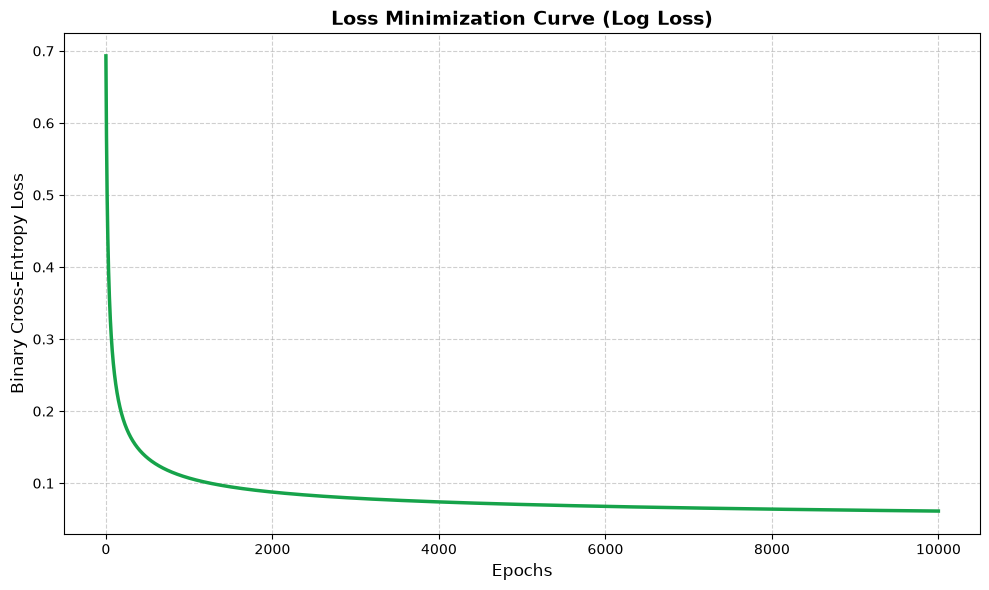

In [4]:
custom_lr_model = BreastCancerLogisticRegression(learning_rate=0.01, epochs=10000, tolerance=1e-7)
custom_lr_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 6))
plt.plot(custom_lr_model.loss_history, color='#16a34a', linewidth=2.5)
plt.title("Loss Minimization Curve (Log Loss)", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Visualizing the Sigmoid Function
The sigmoid function transforms the linear combination of features (z-value) into a probability between 0 and 1.

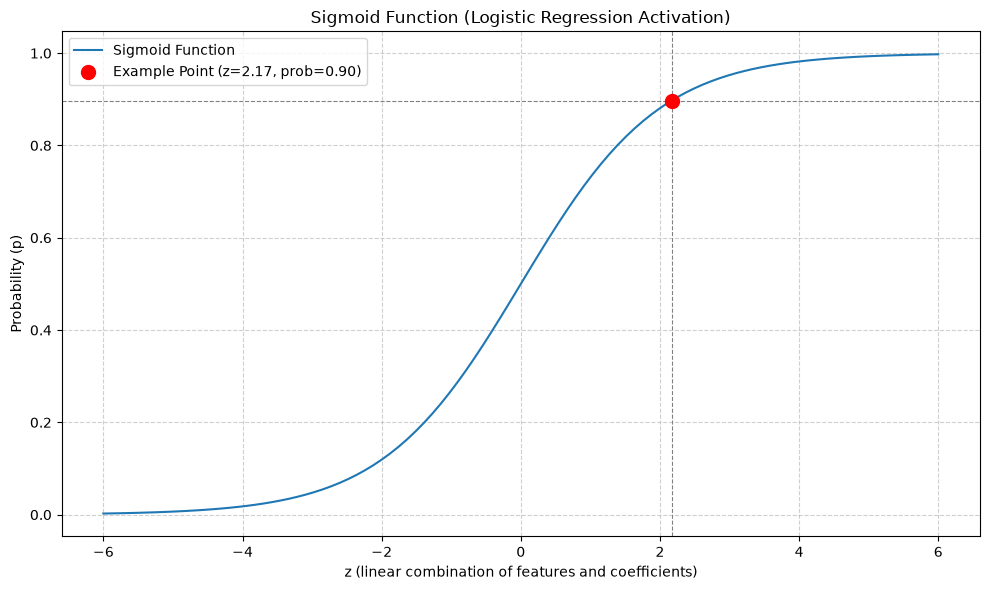

In [5]:
sample = X_test_scaled[0]
z_val = np.dot(custom_lr_model.weights, sample) + custom_lr_model.bias
prob_val = 1 / (1 + np.exp(-z_val))

z_values = np.linspace(-6, 6, 100)
sigmoid_probs = 1 / (1 + np.exp(-z_values))

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_probs, label='Sigmoid Function')
plt.scatter(z_val, prob_val, color='red', s=100, zorder=5, label=f'Example Point (z={z_val:.2f}, prob={prob_val:.2f})')
plt.axvline(x=z_val, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=prob_val, color='gray', linestyle='--', linewidth=0.8)
plt.title('Sigmoid Function (Logistic Regression Activation)')
plt.xlabel('z (linear combination of features and coefficients)')
plt.ylabel('Probability (p)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Train Scikit-Learn Logistic Regression and KNN
We use Scikit-Learn to train both a standard Logistic Regression and a K-Nearest Neighbors classifier for comparison.

In [6]:
# Scikit-Learn Logistic Regression
sk_lr_model = LogisticRegression(random_state=42)
sk_lr_model.fit(X_train_scaled, y_train)
y_pred_lr = sk_lr_model.predict(X_test_scaled)

# Scikit-Learn KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

## 7. Model Evaluation and Confusion Matrices
We evaluate both classifiers using standard metrics and visualize their confusion matrices side-by-side.

--- Logistic Regression (Scikit-Learn) ---
Accuracy:  0.9737
Precision: 0.9722
Recall:    0.9859
F1 Score:  0.9790

--- K-Nearest Neighbors (KNN) ---
Accuracy:  0.9474
Precision: 0.9577
Recall:    0.9577
F1 Score:  0.9577



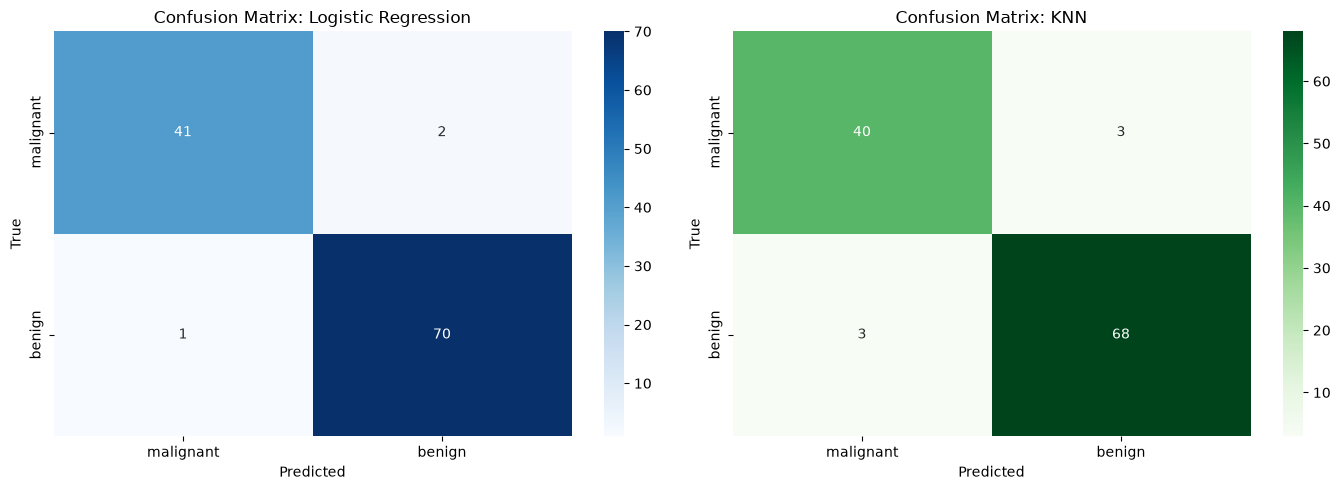

In [7]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}\n")

evaluate_model(y_test, y_pred_lr, "Logistic Regression (Scikit-Learn)")
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix: KNN')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## 8. Conclusion and Final Comparison
**Result Interpretation:** Both Logistic Regression and KNN perform exceptionally well on this dataset after feature scaling.

**Conclusion:** Logistic Regression generally offers slight improvements in interpretability (providing feature weights) and robustness to noise, making it the preferred classifier for this diagnostic task.